# Face Parsing & Facial Metrics Analysis

This notebook performs comprehensive facial segmentation and extracts detailed facial metrics including measurements, angles, and ratios.

## Key Features:
- Facial part segmentation (19 facial regions)
- Individual facial part extraction and visualization
- Comprehensive metrics calculation (angles, dimensions, ratios)
- MediaPipe-based landmark detection
- Detailed metrics export and visualization

## 1. Setup & Dependencies

In [6]:
!pip install -q transformers accelerate pillow matplotlib opencv-python mediapipe scikit-image pandas


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!pip install protobuf==5.29.5
!pip install tensorflow==2.19.0
!pip install mediapipe==0.10.21


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement tensorflow==2.19.0 (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow==2.19.0
ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.21 (from versions: 0.10.30, 0.10.31, 0.10.32, 0.10.33, 0.10.35)

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for mediapipe==0.10.21


In [8]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import os
from PIL import Image
from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation,
)
import mediapipe as mp
from scipy import ndimage

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## 2. Load Face Parsing Model

In [9]:
# Initialize face parsing model (SegFormer)
processor = SegformerImageProcessor.from_pretrained(
    "jonathandinu/face-parsing"
)

model = SegformerForSemanticSegmentation.from_pretrained(
    "jonathandinu/face-parsing"
)

model.to(device)
model.eval()

print("Face Parsing Model Loaded Successfully")

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Face Parsing Model Loaded Successfully


## 3. Load and Preprocess Image

Image loaded: (1500, 2000)


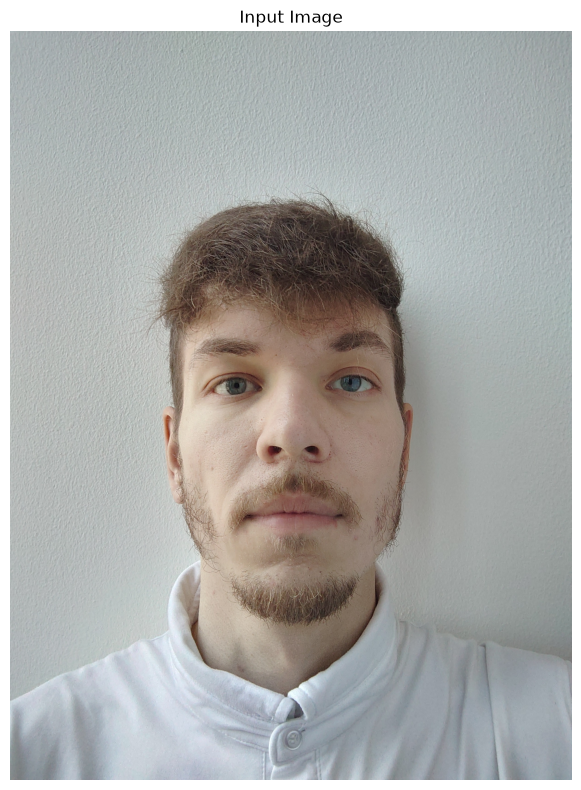

In [10]:
# Upload image (for local use, replace with local path)
# For Colab:
# from google.colab import files
# uploaded = files.upload()
# image_path = list(uploaded.keys())[0]

# For local use:
image_path = "front.png"  # Replace with your image path

if os.path.exists(image_path):
    image = Image.open(image_path).convert("RGB")
    img_rgb = np.array(image)
    print(f"Image loaded: {image.size}")
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"Please provide an image at path: {image_path}")

## 4. Face Segmentation

In [11]:
# Define facial part labels
LABEL_MAP = {
    0: "background",
    1: "skin",
    2: "nose",
    3: "eye_g",
    4: "left_eye",
    5: "right_eye",
    6: "left_eyebrow",
    7: "right_eyebrow",
    8: "left_ear",
    9: "right_ear",
    10: "mouth",
    11: "upper_lip",
    12: "lower_lip",
    13: "hair",
    14: "hat",
    15: "earring",
    16: "necklace",
    17: "neck",
    18: "cloth",
}

print(f"Total facial regions: {len(LABEL_MAP)}")

Total facial regions: 19


In [12]:
# Run segmentation
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

# Upsample to original image size
upsampled_logits = torch.nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)

labels = upsampled_logits.argmax(dim=1)[0]
labels = labels.cpu().numpy()

print(f"Segmentation complete. Unique labels detected: {np.unique(labels)}")

Segmentation complete. Unique labels detected: [ 0  1  2  4  5  6  7  8  9 11 12 13 17 18]


## 5. Visualize Segmentation Masks

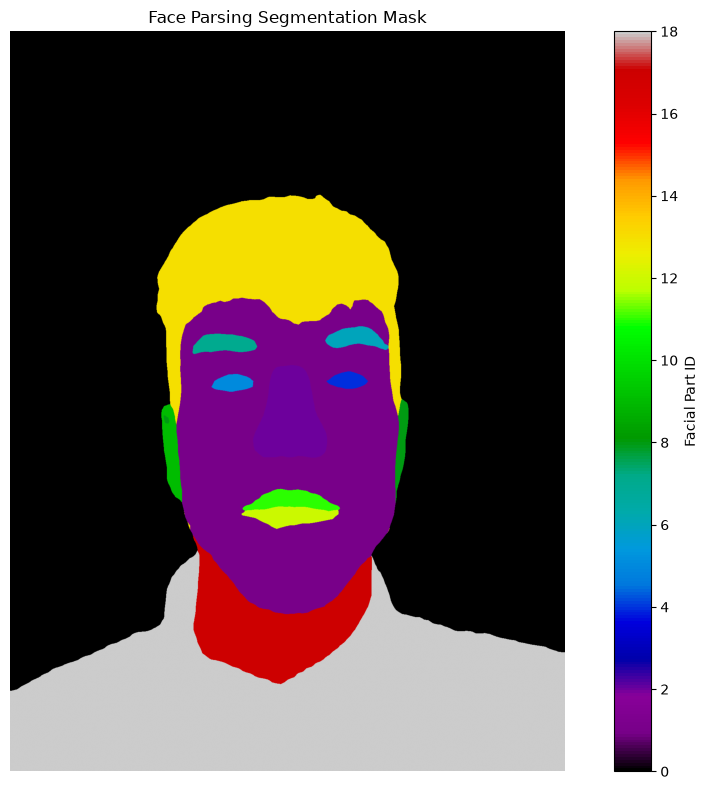

In [13]:
# Display full segmentation map
plt.figure(figsize=(10, 8))
plt.imshow(labels, cmap="nipy_spectral")
plt.colorbar(label="Facial Part ID")
plt.title("Face Parsing Segmentation Mask")
plt.axis("off")
plt.tight_layout()
plt.show()

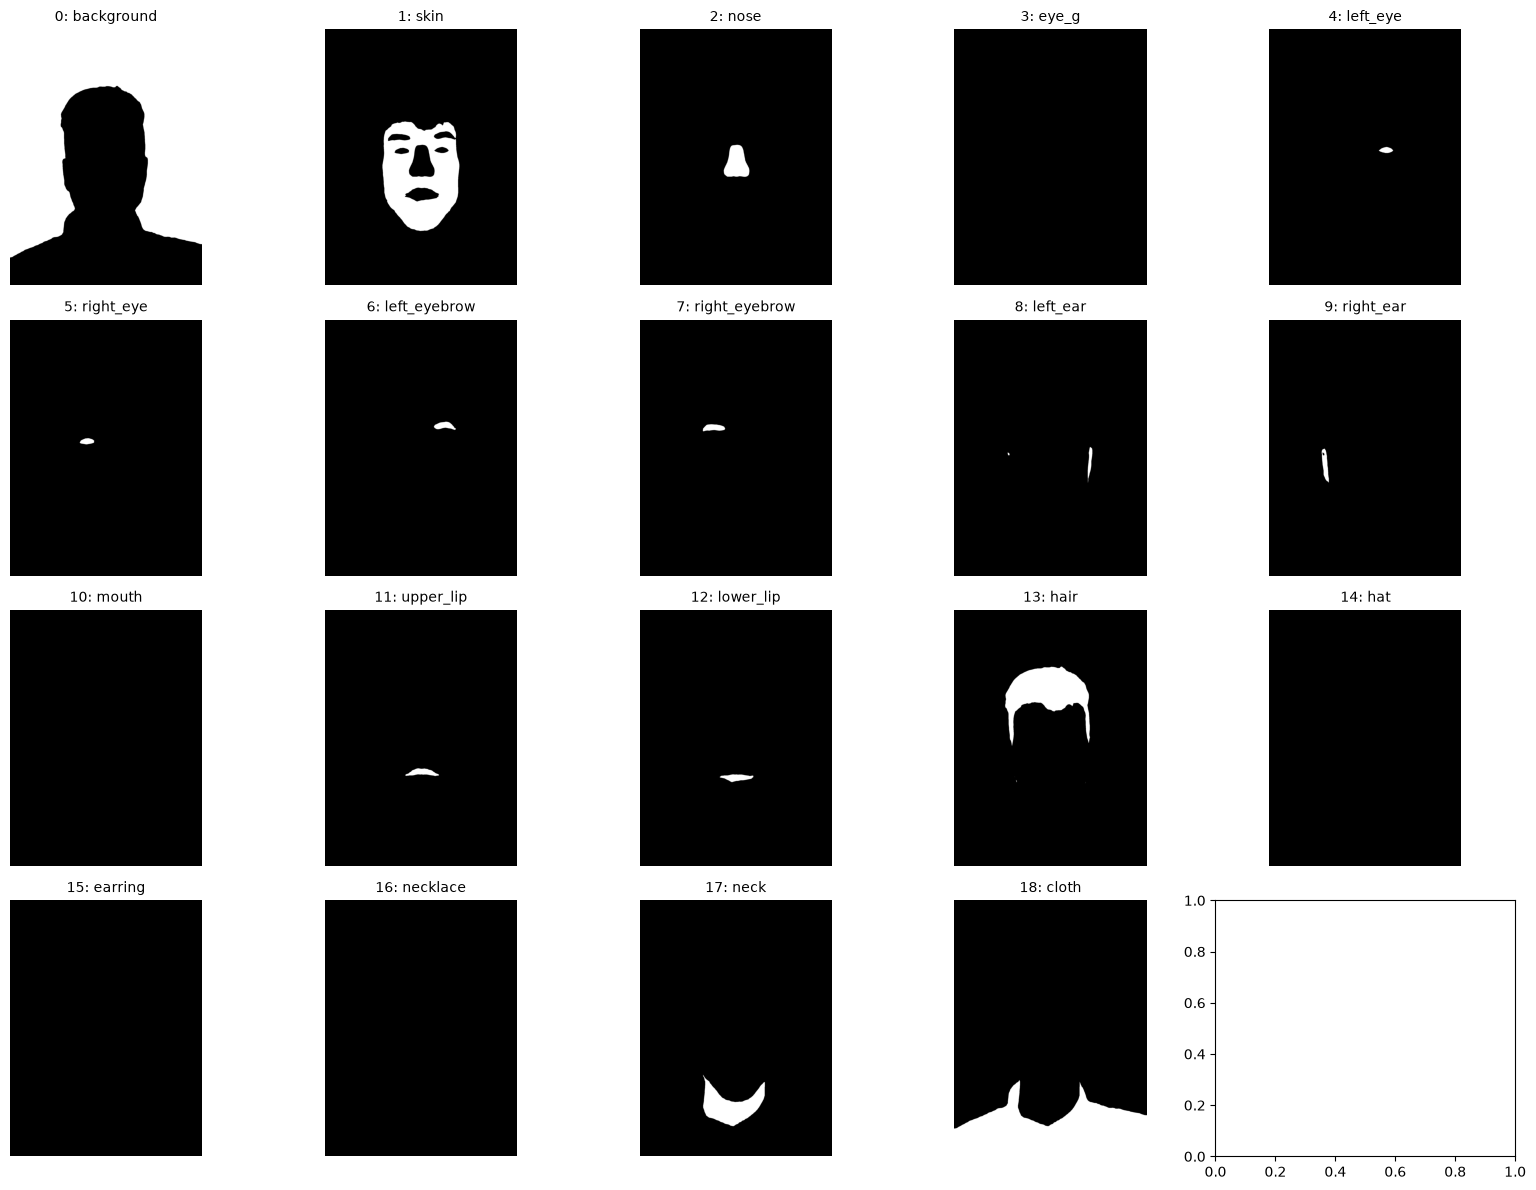

In [14]:
# Display individual segmentation masks
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
axes = axes.flatten()

for idx, name in LABEL_MAP.items():
    mask = (labels == idx)
    axes[idx].imshow(mask, cmap="gray")
    axes[idx].set_title(f"{idx}: {name}", fontsize=10)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 6. Extract Individual Facial Parts

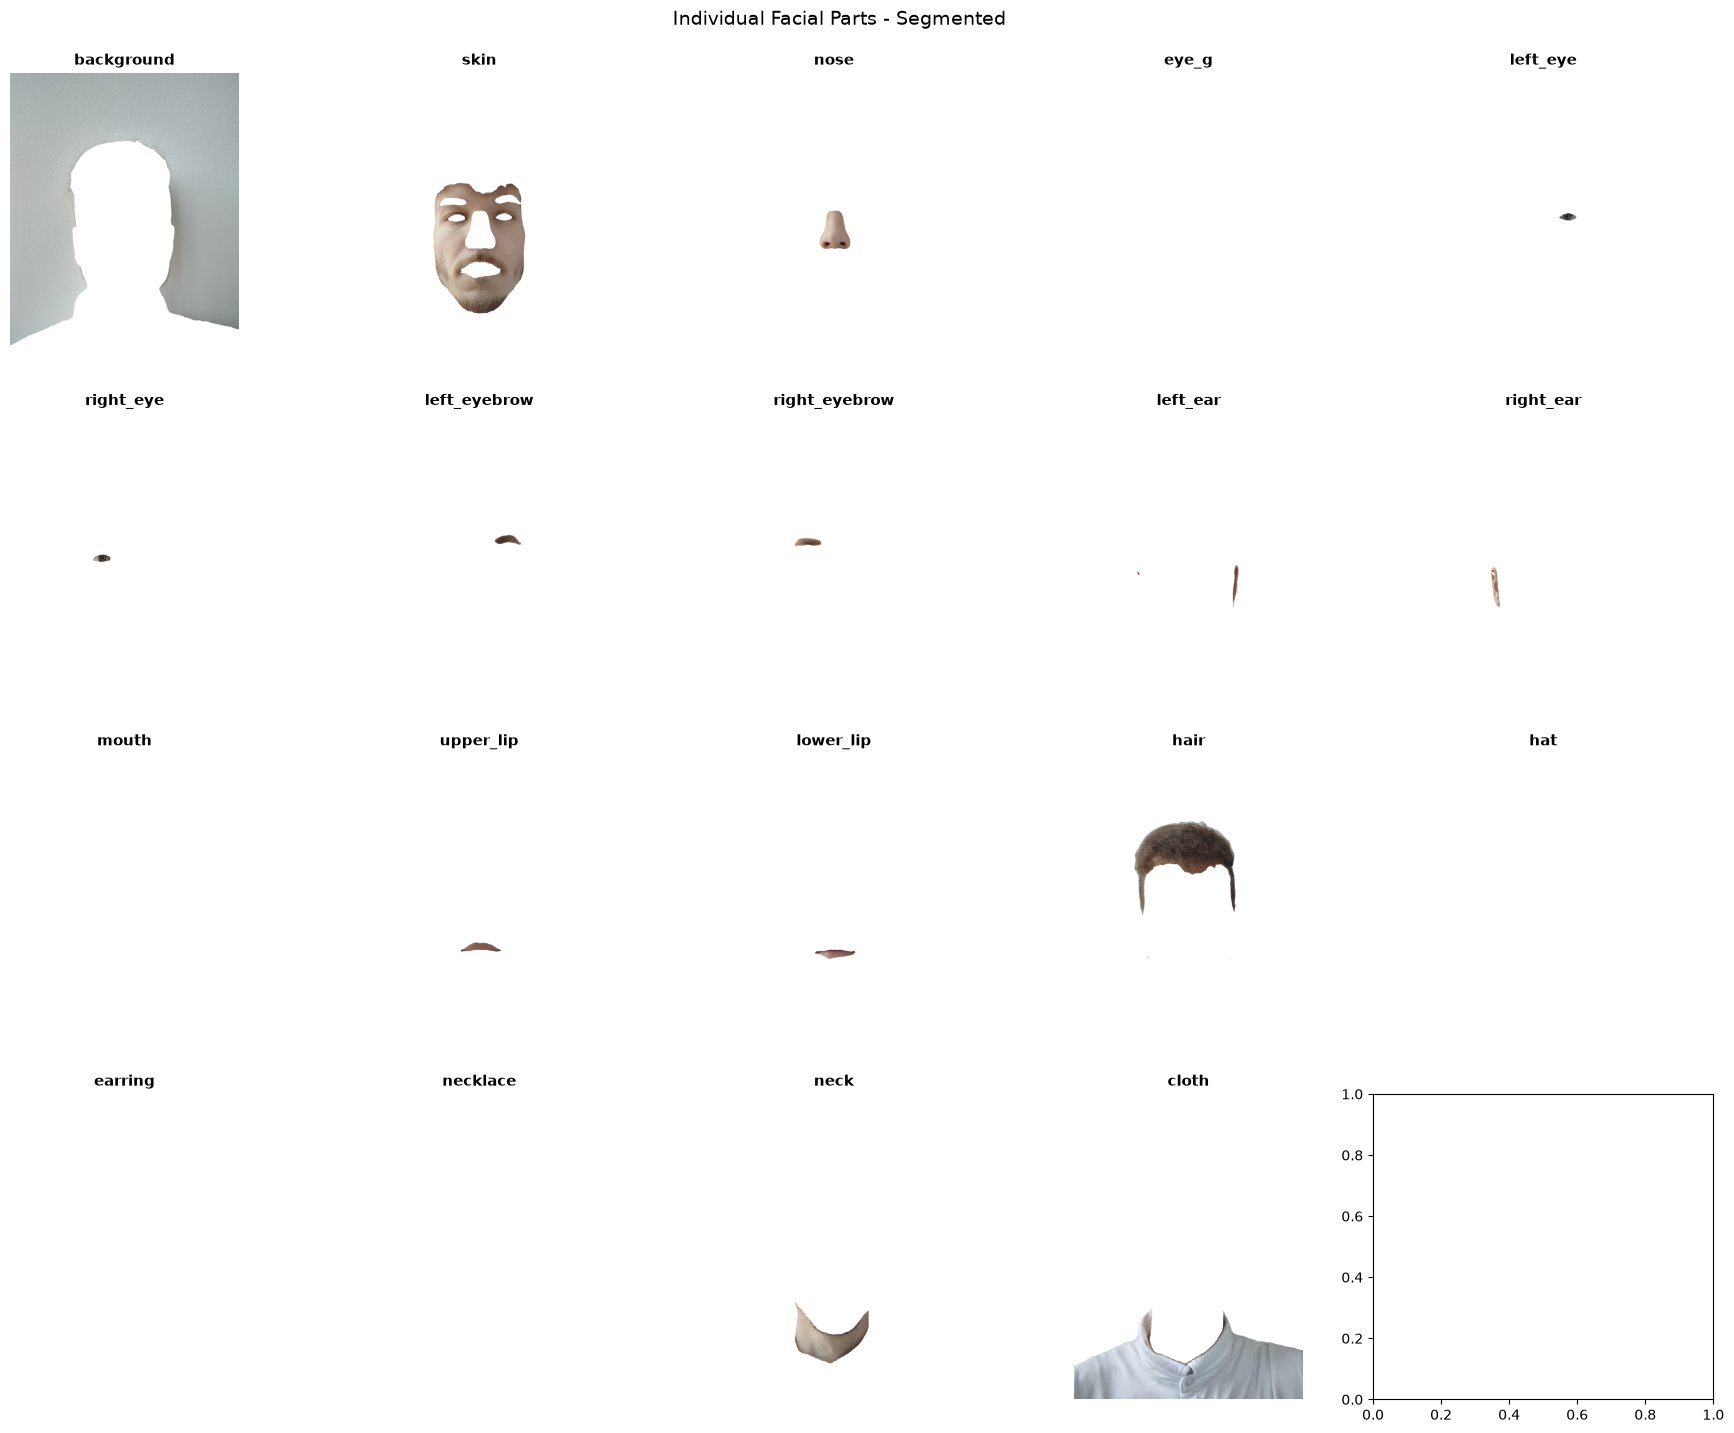

In [15]:
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes = axes.flatten()

for idx in range(len(LABEL_MAP)):
    mask = labels == idx

    # White background
    part = np.ones_like(img_rgb) * 255

    # Copy only the segmented part
    part[mask] = img_rgb[mask]

    axes[idx].imshow(part)
    axes[idx].set_title(LABEL_MAP[idx], fontsize=11, fontweight="bold")
    axes[idx].axis("off")

plt.tight_layout()
plt.suptitle("Individual Facial Parts - Segmented", fontsize=14, y=1.02)
plt.show()

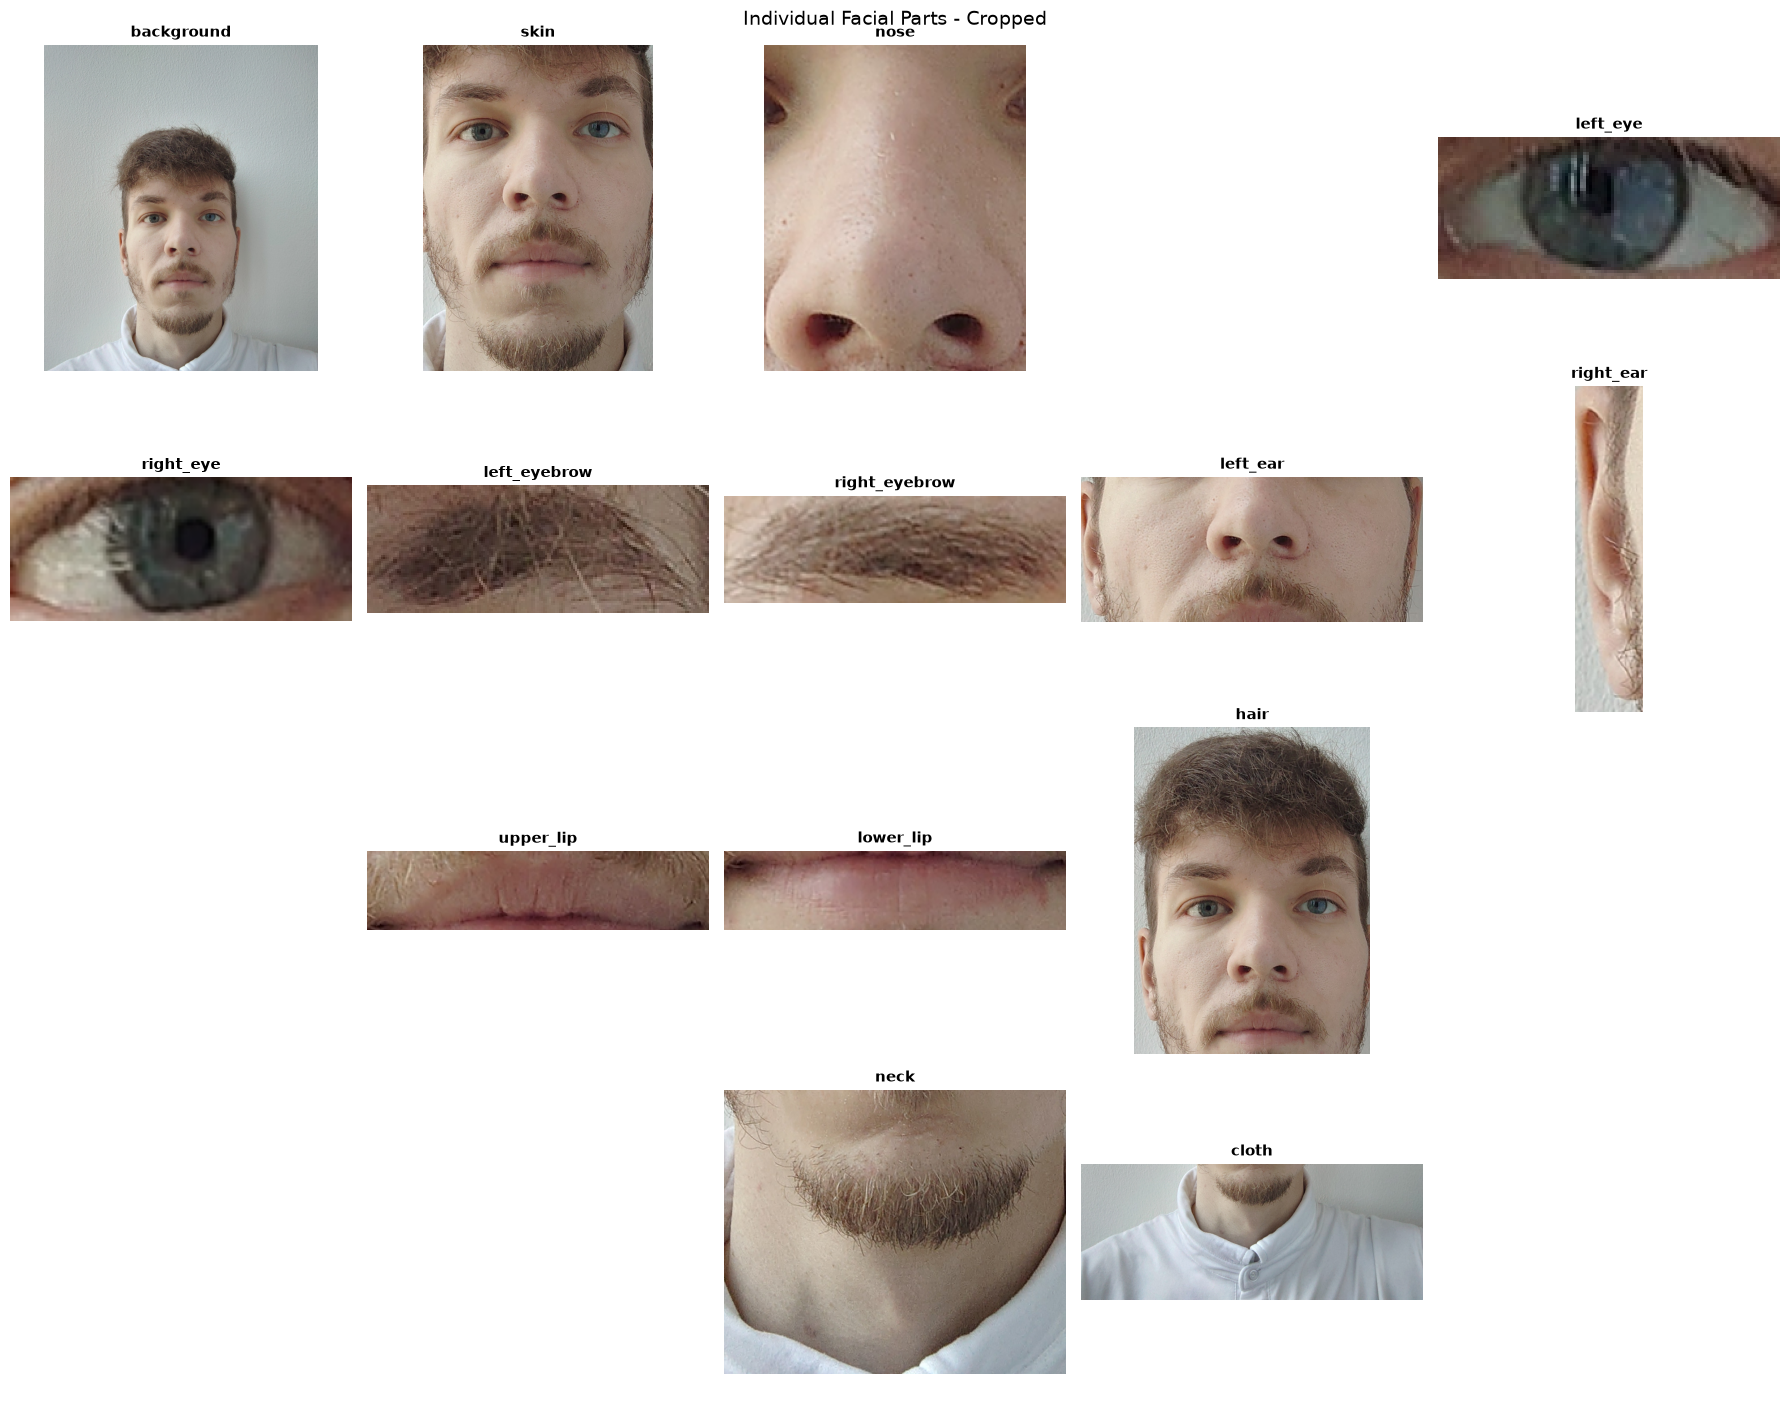

In [16]:
# Extract and display cropped facial parts
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes = axes.flatten()

for idx in range(len(LABEL_MAP)):
    mask = (labels == idx)
    ys, xs = np.where(mask)

    if len(xs) == 0:
        axes[idx].axis("off")
        continue

    # Calculate bounding box
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    crop = img_rgb[y1:y2+1, x1:x2+1]

    axes[idx].imshow(crop)
    axes[idx].set_title(LABEL_MAP[idx], fontsize=11, fontweight="bold")
    axes[idx].axis("off")

for i in range(len(LABEL_MAP), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.suptitle("Individual Facial Parts - Cropped", fontsize=14, y=1.00)
plt.show()

## 7. Load MediaPipe Face Landmarks

In [18]:
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
import mediapipe as mp

# Initialize MediaPipe Face Landmarker (Tasks API)
base_options = mp_python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1
)
detector = vision.FaceLandmarker.create_from_options(options)

# Detect landmarks
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
detection_result = detector.detect(mp_image)

class MockLandmarks:
    def __init__(self, lms):
        self.landmark = lms

if detection_result.face_landmarks:
    landmarks = MockLandmarks(detection_result.face_landmarks[0])
    print(f"Face landmarks detected: {len(landmarks.landmark)} points")
else:
    print("No face landmarks detected!")


Face landmarks detected: 478 points


In [19]:
# Extract landmark coordinates in pixel space
h, w = img_rgb.shape[:2]
landmark_points = []

for lm in landmarks.landmark:
    x = int(lm.x * w)
    y = int(lm.y * h)
    landmark_points.append((x, y))

landmark_points = np.array(landmark_points)
print(f"Landmarks array shape: {landmark_points.shape}")

Landmarks array shape: (478, 2)


## 8. Define Measurement Functions

In [20]:
def lm_px(idx):
    """Get landmark coordinates in pixel space."""
    return landmark_points[idx]

def dist_px(idx1, idx2):
    """Euclidean distance between two landmarks in pixels."""
    p1, p2 = lm_px(idx1), lm_px(idx2)
    return float(np.linalg.norm(p2 - p1))

def angle_deg(vertex_idx, a_idx, b_idx):
    """Angle (deg) at vertex between rays vertex->a and vertex->b."""
    v, a, b = lm_px(vertex_idx), lm_px(a_idx), lm_px(b_idx)
    va, vb = a - v, b - v
    cos_a = np.dot(va, vb) / (np.linalg.norm(va) * np.linalg.norm(vb) + 1e-9)
    return float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))

def angle_from_vertical(idx_top, idx_bottom):
    """Angle from vertical for a vector."""
    vec = lm_px(idx_bottom) - lm_px(idx_top)
    cos_a = np.dot(vec, [0, 1]) / (np.linalg.norm(vec) + 1e-9)
    return float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))

def angle_from_horizontal(idx_a, idx_b):
    """Angle from horizontal for a vector."""
    vec = lm_px(idx_b) - lm_px(idx_a)
    cos_a = np.dot(vec, [1, 0]) / (np.linalg.norm(vec) + 1e-9)
    return float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))

def curvature_ratio(p_start_idx, p_mid_idx, p_end_idx):
    """Sagitta/chord ratio: 0 = flat line, higher = more arched."""
    p1, p2, p3 = lm_px(p_start_idx), lm_px(p_mid_idx), lm_px(p_end_idx)
    chord = p3 - p1
    chord_len = np.linalg.norm(chord)
    if chord_len < 1e-6:
        return 0.0
    t = np.dot(p2 - p1, chord) / (chord_len ** 2)
    proj = p1 + t * chord
    sagitta = np.linalg.norm(p2 - proj)
    return float(sagitta / chord_len)

def eye_aspect_ratio(p1, p2, p3, p4, p5, p6):
    """Eye Aspect Ratio (EAR): (|p2-p6| + |p3-p5|) / (2*|p1-p4|)."""
    p1, p2, p3, p4, p5, p6 = [lm_px(i) for i in (p1, p2, p3, p4, p5, p6)]
    vertical = np.linalg.norm(p2 - p6) + np.linalg.norm(p3 - p5)
    horizontal = np.linalg.norm(p1 - p4)
    return float(vertical / (2 * horizontal + 1e-9))

def point_line_deviation_px(point_idx, line_idx1, line_idx2):
    """Perpendicular distance (px) of point from line."""
    p, a, b = lm_px(point_idx), lm_px(line_idx1), lm_px(line_idx2)
    ab = b - a
    t = np.dot(p - a, ab) / (np.dot(ab, ab) + 1e-9)
    proj = a + t * ab
    return float(np.linalg.norm(p - proj))

print("Measurement functions defined successfully")

Measurement functions defined successfully


## 9. Calculate Facial Metrics

In [21]:
# Define reference landmarks
FOREHEAD_TOP   = 10
GLABELLA       = 9      # between eyebrows
NOSE_TIP       = 4
NOSE_BRIDGE    = 168
SUBNASALE      = 2      # nose base
MENTON         = 152    # chin bottom
R_ZYGION       = 234    # right cheekbone
L_ZYGION       = 454    # left cheekbone
R_TEMPLE       = 127
L_TEMPLE       = 356
R_GONION       = 172    # right jaw angle
L_GONION       = 397    # left jaw angle

# Calculate face dimensions (pixel space)
face_width_px  = dist_px(R_ZYGION, L_ZYGION)
face_height_px = dist_px(FOREHEAD_TOP, MENTON)
ipd_px = dist_px(33, 263)  # Inter-pupil distance

# Estimate mm_per_px (assuming 63.5mm average interpupil distance)
mm_per_px = 63.5 / (ipd_px + 1e-9)

print(f"Face dimensions (pixels): {face_width_px:.1f} x {face_height_px:.1f}")
print(f"Inter-pupil distance: {ipd_px:.1f} px")
print(f"Scaling factor: {mm_per_px:.4f} mm/px")

Face dimensions (pixels): 591.1 x 794.1
Inter-pupil distance: 429.1 px
Scaling factor: 0.1480 mm/px


In [22]:
metrics = {}  # category -> {metric_name: (value, unit)}

# --- EYEBROWS ---
R_BROW_INNER, R_BROW_PEAK, R_BROW_OUTER = 55, 105, 70
L_BROW_INNER, L_BROW_PEAK, L_BROW_OUTER = 285, 334, 300
R_EYE_TOP, R_EYE_BOTTOM = 159, 145
L_EYE_TOP, L_EYE_BOTTOM = 386, 374

metrics["eyebrow"] = {
    "right_brow_peak_height_mm": (
        abs(lm_px(R_BROW_PEAK)[1] - lm_px(R_EYE_TOP)[1]) * mm_per_px, "mm"),
    "left_brow_peak_height_mm": (
        abs(lm_px(L_BROW_PEAK)[1] - lm_px(L_EYE_TOP)[1]) * mm_per_px, "mm"),
    "right_brow_elevation_ratio": (
        abs(lm_px(R_BROW_PEAK)[1] - lm_px(R_EYE_TOP)[1]) / (ipd_px + 1e-9), "ratio"),
    "left_brow_elevation_ratio": (
        abs(lm_px(L_BROW_PEAK)[1] - lm_px(L_EYE_TOP)[1]) / (ipd_px + 1e-9), "ratio"),
    "right_brow_apex_angle_deg": (
        angle_deg(R_BROW_PEAK, R_BROW_INNER, R_BROW_OUTER), "deg"),
    "left_brow_apex_angle_deg": (
        angle_deg(L_BROW_PEAK, L_BROW_INNER, L_BROW_OUTER), "deg"),
}

print("✓ Eyebrow metrics calculated")

✓ Eyebrow metrics calculated


In [23]:
# --- EYES ---
metrics["eye"] = {
    "right_eye_aspect_ratio": (
        eye_aspect_ratio(33, 160, 158, 133, 153, 144), "ratio"),
    "left_eye_aspect_ratio": (
        eye_aspect_ratio(362, 385, 387, 263, 373, 380), "ratio"),
    "eye_spacing_ipd_over_face_width": (
        ipd_px / (face_width_px + 1e-9), "ratio"),
    "right_lower_eyelid_curvature": (
        curvature_ratio(33, R_EYE_BOTTOM, 133), "ratio"),
    "left_lower_eyelid_curvature": (
        curvature_ratio(362, L_EYE_BOTTOM, 263), "ratio"),
}

print("✓ Eye metrics calculated")

✓ Eye metrics calculated


In [24]:
# --- NOSE ---
R_ALA, L_ALA = 129, 358  # nostril wings
R_BRIDGE_SIDE, L_BRIDGE_SIDE = 236, 456
R_INNER_CANTHUS, L_INNER_CANTHUS = 133, 362

nose_width_px = dist_px(R_ALA, L_ALA)
nose_height_px = dist_px(NOSE_BRIDGE, SUBNASALE)
intercanthal_px = dist_px(R_INNER_CANTHUS, L_INNER_CANTHUS)

metrics["nose"] = {
    "nasal_width_mm": (nose_width_px * mm_per_px, "mm"),
    "nasal_height_mm": (nose_height_px * mm_per_px, "mm"),
    "nasal_aspect_ratio_width_over_height": (
        nose_width_px / (nose_height_px + 1e-9), "ratio"),
    "naso_canthal_ratio_nose_width_over_intercanthal": (
        nose_width_px / (intercanthal_px + 1e-9), "ratio"),
    "pyramidal_width_mm": (
        dist_px(R_BRIDGE_SIDE, L_BRIDGE_SIDE) * mm_per_px, "mm"),
}

print("✓ Nose metrics calculated")

✓ Nose metrics calculated


In [25]:
# --- LIPS ---
MOUTH_R, MOUTH_L = 61, 291
CUPID_DIP = 0
CUPID_PEAK_R, CUPID_PEAK_L = 37, 267
LOWER_LIP_BOTTOM = 17

mouth_width_px = dist_px(MOUTH_R, MOUTH_L)

metrics["lips"] = {
    "mouth_width_mm": (mouth_width_px * mm_per_px, "mm"),
    "philtrum_length_mm": (dist_px(SUBNASALE, CUPID_DIP) * mm_per_px, "mm"),
    "cupids_bow_angle_deg": (
        angle_deg(CUPID_DIP, CUPID_PEAK_R, CUPID_PEAK_L), "deg"),
}

print("✓ Lips metrics calculated")

✓ Lips metrics calculated


In [26]:
# --- CHEEKS ---
metrics["cheeks"] = {
    "facial_width_mm": (face_width_px * mm_per_px, "mm"),
    "malar_width_ratio_powell": (
        face_width_px / (face_height_px + 1e-9), "ratio"),
    "right_cheekbone_vertical_position_ratio": (
        (lm_px(R_ZYGION)[1] - lm_px(FOREHEAD_TOP)[1]) / (face_height_px + 1e-9), "ratio (0=forehead, 1=chin)"),
    "left_cheekbone_vertical_position_ratio": (
        (lm_px(L_ZYGION)[1] - lm_px(FOREHEAD_TOP)[1]) / (face_height_px + 1e-9), "ratio (0=forehead, 1=chin)"),
}

print("✓ Cheeks metrics calculated")

✓ Cheeks metrics calculated


In [27]:
# --- JAW ---
jaw_width_px = dist_px(R_GONION, L_GONION)

metrics["jaw"] = {
    "frontal_jaw_rise_mm": (
        abs(lm_px(R_GONION)[1] - lm_px(MENTON)[1]) * mm_per_px, "mm"),
    "jaw_width_mm": (jaw_width_px * mm_per_px, "mm"),
    "right_jaw_inclination_angle_deg": (
        angle_from_horizontal(R_GONION, MENTON), "deg"),
    "left_jaw_inclination_angle_deg": (
        angle_from_horizontal(L_GONION, MENTON), "deg"),
    "face_width_mm": (face_width_px * mm_per_px, "mm"),
}

print("✓ Jaw metrics calculated")

✓ Jaw metrics calculated


In [ ]:
# --- CHIN ---
CHIN_R, CHIN_L = 214, 434

metrics["chin"] = {
    "chin_width_mm": (dist_px(CHIN_R, CHIN_L) * mm_per_px, "mm"),
    "chin_vertical_height_mm": (
        dist_px(LOWER_LIP_BOTTOM, MENTON) * mm_per_px, "mm"),
    "chin_midline_deviation_mm": (
        point_line_deviation_px(MENTON, GLABELLA, NOSE_TIP) * mm_per_px, "mm"),
}

print("✓ Chin metrics calculated")

In [ ]:
# --- HAIR / FOREHEAD ---
metrics["hair"] = {
    "forehead_width_mm": (dist_px(R_TEMPLE, L_TEMPLE) * mm_per_px, "mm"),
    "forehead_height_mm_mesh_approx": (
        dist_px(FOREHEAD_TOP, GLABELLA) * mm_per_px, "mm"),
    "right_temple_inclination_angle_deg": (
        angle_from_vertical(R_TEMPLE, R_ZYGION), "deg"),
    "left_temple_inclination_angle_deg": (
        angle_from_vertical(L_TEMPLE, L_ZYGION), "deg"),
}

print("✓ Hair/Forehead metrics calculated")

In [ ]:
# --- SMILE ---
metrics["smile"] = {
    "upper_smile_arc_curvature": (
        curvature_ratio(MOUTH_R, CUPID_DIP, MOUTH_L), "ratio"),
    "lower_smile_arc_curvature": (
        curvature_ratio(MOUTH_R, LOWER_LIP_BOTTOM, MOUTH_L), "ratio"),
    "smile_width_mm": (mouth_width_px * mm_per_px, "mm"),
}

print("✓ Smile metrics calculated")

In [ ]:
# --- NECK (from segmentation mask) ---
neck_mask = (labels == 17)
neck_pixels = np.where(neck_mask)

if len(neck_pixels[0]) > 0:
    ys, xs = neck_pixels
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    neck_width_px = x2 - x1

    metrics["neck"] = {
        "neck_width_mm": (neck_width_px * mm_per_px, "mm"),
        "neck_width_to_jaw_width_ratio": (
            neck_width_px / (jaw_width_px + 1e-9), "ratio"),
    }
else:
    metrics["neck"] = {
        "neck_width_mm": (None, "mm - not detected"),
        "neck_width_to_jaw_width_ratio": (None, "ratio - not detected"),
    }

print("✓ Neck metrics calculated")

## 10. Display All Metrics

In [ ]:
# Flatten metrics into DataFrame
rows = []
for category, m in metrics.items():
    for name, (value, unit) in m.items():
        rows.append({
            "Category": category.upper(),
            "Metric": name,
            "Value": round(value, 3) if isinstance(value, (int, float)) else value,
            "Unit": unit,
        })

metrics_df = pd.DataFrame(rows)

# Display all metrics
print("\n" + "="*100)
print("COMPREHENSIVE FACIAL METRICS")
print("="*100 + "\n")
print(metrics_df.to_string(index=False))
print("\n" + "="*100)

## 11. Metrics Summary by Category

In [ ]:
# Display metrics grouped by category
print("\nMETRICS SUMMARY BY CATEGORY\n")
for category in metrics_df["Category"].unique():
    print(f"\n{'='*90}")
    print(f"  {category}")
    print(f"{'='*90}")
    category_df = metrics_df[metrics_df["Category"] == category]
    for _, row in category_df.iterrows():
        print(f"  {row['Metric']:.<50} {row['Value']:>15} {row['Unit']}")

## 12. Export Results

In [ ]:
# Save metrics to CSV
output_csv = "facial_metrics.csv"
metrics_df.to_csv(output_csv, index=False)
print(f"✓ Metrics saved to: {output_csv}")

# Display file size
if os.path.exists(output_csv):
    size = os.path.getsize(output_csv)
    print(f"  File size: {size} bytes")

## 13. Visualization of Landmarks and Metrics

In [ ]:
# Visualize selected landmarks on the image
def plot_landmarks(indices, labels_text=None, title="Facial Landmarks"):
    """Overlay landmarks on the image."""
    vis = img_rgb.copy()
    for i, idx in enumerate(indices):
        x, y = lm_px(idx).astype(int)
        cv2.circle(vis, (x, y), 5, (0, 255, 0), -1)
        text = labels_text[i] if labels_text else str(idx)
        cv2.putText(vis, text, (x + 8, y - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2, cv2.LINE_AA)
    plt.figure(figsize=(10, 10))
    plt.imshow(vis)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Plot key reference landmarks
key_indices = [
    FOREHEAD_TOP, GLABELLA, NOSE_TIP, NOSE_BRIDGE, SUBNASALE, MENTON,
    R_ZYGION, L_ZYGION, R_TEMPLE, L_TEMPLE, R_GONION, L_GONION
]
key_labels = [
    "Forehead", "Glabella", "Nose Tip", "Nose Bridge", "Subnasale", "Menton",
    "R_Zygion", "L_Zygion", "R_Temple", "L_Temple", "R_Gonion", "L_Gonion"
]

plot_landmarks(key_indices, key_labels, "Key Facial Reference Landmarks")

In [ ]:
# Plot eyebrow landmarks
eyebrow_indices = [R_BROW_INNER, R_BROW_PEAK, R_BROW_OUTER, L_BROW_INNER, L_BROW_PEAK, L_BROW_OUTER]
eyebrow_labels = ["R_Inner", "R_Peak", "R_Outer", "L_Inner", "L_Peak", "L_Outer"]
plot_landmarks(eyebrow_indices, eyebrow_labels, "Eyebrow Landmarks")

In [ ]:
# Plot eye landmarks
eye_indices = [33, 160, 158, 133, 153, 144, 362, 385, 387, 263, 373, 380]
eye_labels = ["R_Outer", "R_Up_L", "R_Up_R", "R_Inner", "R_Down_L", "R_Down_R",
               "L_Outer", "L_Up_L", "L_Up_R", "L_Inner", "L_Down_L", "L_Down_R"]
plot_landmarks(eye_indices, eye_labels, "Eye Landmarks")

In [ ]:
# Plot mouth/lips landmarks
mouth_indices = [MOUTH_R, MOUTH_L, CUPID_DIP, CUPID_PEAK_R, CUPID_PEAK_L, LOWER_LIP_BOTTOM, SUBNASALE]
mouth_labels = ["R_Corner", "L_Corner", "Cupid_Dip", "R_Peak", "L_Peak", "Lower_Bottom", "Subnasale"]
plot_landmarks(mouth_indices, mouth_labels, "Mouth & Lips Landmarks")

## 14. Statistics and Summary

In [ ]:
# Summary statistics
print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)

# Count metrics by type
mm_metrics = len(metrics_df[metrics_df["Unit"] == "mm"])
ratio_metrics = len(metrics_df[metrics_df["Unit"].str.contains("ratio", na=False)])
deg_metrics = len(metrics_df[metrics_df["Unit"] == "deg"])

print(f"\nMetrics by Type:")
print(f"  • Measurements (mm):        {mm_metrics}")
print(f"  • Ratios:                   {ratio_metrics}")
print(f"  • Angles (deg):             {deg_metrics}")
print(f"  • Total Metrics:            {len(metrics_df)}")

print(f"\nFacial Regions Analyzed:")
for i, cat in enumerate(metrics_df["Category"].unique(), 1):
    count = len(metrics_df[metrics_df["Category"] == cat])
    print(f"  {i:2d}. {cat:.<40} {count:>3} metrics")

print(f"\nImage Resolution: {img_rgb.shape[1]} x {img_rgb.shape[0]} pixels")
print(f"Face Dimensions: {face_width_px:.1f} x {face_height_px:.1f} pixels")
print(f"Scaling Factor: {mm_per_px:.6f} mm/pixel")
print("\n" + "="*80)